# LankaMart Sales Analysis Project

**Name** : Muthuthanthri Patabadige Tharusha Nethmina Cooray \
**Phone number** : 0766055943 \
AI/ML Ignition Program Batch No.1


## 1. Import Libraries
These libraries are used for data handling and visualization.

In [660]:
#Import numpy, pandas, matplotlib , and seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline


## 2. Load Dataset
Load the dataset to start analysis.

In [661]:
# Read the dataset

df = pd.read_csv("supermarket_sales_srilanka_1500.csv")

# Display the first few rows of the dataset

df.head()


,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Category,Unit_Price,Quantity,Total,Date,Time,Payment,Rating
0,SLM-100001,Galle,Galle,Member,Male,Household,584.33,5,2629.49,2026-02-15,21:51,Cash,6.8
1,SLM-100002,Kandy,Kandy,Member,Male,Household,3170.80,3,9131.90,2026-01-14,15:55,Cash,7.7
2,SLM-100003,Galle,Galle,Normal,Male,Beverages,925.68,6,4998.67,2026-02-16,19:45,Card,6.7
3,SLM-100004,Colombo,Colombo,Member,Female,Personal Care,2521.37,6,17851.30,2026-02-17,13:40,Cash,8.0
4,SLM-100005,Kandy,Kandy,Member,Male,Household,1801.89,6,10378.89,2026-02-16,18:37,eZ Cash,7.9


## 3. Data Overview
Understand dataset size, structure, and basic statistics.

In [662]:
# Check the shape, info, and summary statistics of the dataset

df.shape
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Invoice_ID        1500 non-null   str    
 1   Branch            1500 non-null   str    
 2   City              1500 non-null   str    
 3   Customer_Type     1500 non-null   str    
 4   Gender            1500 non-null   str    
 5   Product_Category  1500 non-null   str    
 6   Unit_Price        1500 non-null   float64
 7   Quantity          1500 non-null   int64  
 8   Total             1500 non-null   float64
 9   Date              1500 non-null   str    
 10  Time              1500 non-null   str    
 11  Payment           1494 non-null   str    
 12  Rating            1492 non-null   float64
dtypes: float64(3), int64(1), str(9)
memory usage: 152.5 KB


,Unit_Price,Quantity,Total,Rating
count,1500.000000,1500.000000,1500.000000,1492.000000
mean,1710.407593,3.917333,7126.569253,7.152547
std,1693.475187,1.794244,8727.972507,1.287150
min,121.380000,1.000000,137.050000,3.100000
25%,601.970000,2.000000,1841.367500,6.200000
50%,1264.445000,4.000000,4183.125000,7.200000
75%,2061.880000,5.000000,8921.992500,8.000000
max,9463.720000,8.000000,71312.050000,10.000000


## 4. Check Missing Values in Each Column


In [663]:
df.isnull().sum()

Invoice_ID          0
Branch              0
City                0
Customer_Type       0
Gender              0
Product_Category    0
Unit_Price          0
Quantity            0
Total               0
Date                0
Time                0
Payment             6
Rating              8
dtype: int64

## 5. Data Cleaning
Fix missing values and clean text fields to ensure accuracy.

In [664]:
# Strip leading and trailing whitespace from Product_Category
df['Product_Category'] = df['Product_Category'].str.strip()

# Fill missing values in Payment with "Unknown"
df['Payment'] = df['Payment'].fillna("Unknown")

# Fill missing values in Rating with mean
df['Rating'] = df['Rating'].fillna(df['Rating'].mean())

# Remove duplicates
df = df.drop_duplicates()


## 6. Date, Time and Calendar Extraction

In [665]:
# Convert Date & Time
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')


# Create new time features
df['Hour'] = df['Time'].dt.hour
df['Day'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name() 

df 

,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Category,Unit_Price,Quantity,Total,Date,Time,Payment,Rating,Hour,Day,Month
0,SLM-100001,Galle,Galle,Member,Male,Household,584.33,5,2629.49,2026-02-15,1900-01-01 21:51:00,Cash,6.8,21,Sunday,February
1,SLM-100002,Kandy,Kandy,Member,Male,Household,3170.80,3,9131.90,2026-01-14,1900-01-01 15:55:00,Cash,7.7,15,Wednesday,January
2,SLM-100003,Galle,Galle,Normal,Male,Beverages,925.68,6,4998.67,2026-02-16,1900-01-01 19:45:00,Card,6.7,19,Monday,February
3,SLM-100004,Colombo,Colombo,Member,Female,Personal Care,2521.37,6,17851.30,2026-02-17,1900-01-01 13:40:00,Cash,8.0,13,Tuesday,February
4,SLM-100005,Kandy,Kandy,Member,Male,Household,1801.89,6,10378.89,2026-02-16,1900-01-01 18:37:00,eZ Cash,7.9,18,Monday,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,SLM-101496,Colombo,Colombo,Normal,Male,Electronics,2226.27,6,15761.99,2026-02-10,1900-01-01 17:55:00,eZ Cash,7.0,17,Tuesday,February
1496,SLM-101497,Kandy,Kandy,Normal,Female,Personal Care,2591.64,5,12439.87,2026-01-19,1900-01-01 20:15:00,Cash,8.2,20,Monday,January
1497,SLM-101498,Kandy,Kandy,Member,Female,Beverages,127.50,6,734.40,2026-01-03,1900-01-01 12:39:00,eZ Cash,6.8,12,Saturday,January
1498,SLM-101499,Galle,Galle,Normal,Female,Beverages,540.00,6,2916.00,2026-01-07,1900-01-01 15:48:00,Card,4.3,15,Wednesday,January


## 7. Total Sales
This shows the overall revenue generated in the dataset.

In [666]:
# Calculate total sales

df['Total_Sales'] = df['Quantity'] * df['Unit_Price']
df['Total_Sales']

0        2921.65
1        9512.40
2        5554.08
3       15128.22
4       10811.34
          ...   
1495    13357.62
1496    12958.20
1497      765.00
1498     3240.00
1499     2051.10
Name: Total_Sales, Length: 1500, dtype: float64

## 8. Sales by Branch
Identify which branch contributes most to total sales.

In [667]:
# Calculate total sales by branch using groupby and sort the results in descending order

branch_sales = df.groupby('Branch')['Total'].sum().sort_values(ascending=False).reset_index()

print("\nMost Sales Branch:\n")
print(branch_sales)


Most Sales Branch:

    Branch       Total
0  Colombo  5507914.09
1    Kandy  2942373.76
2    Galle  2239566.03


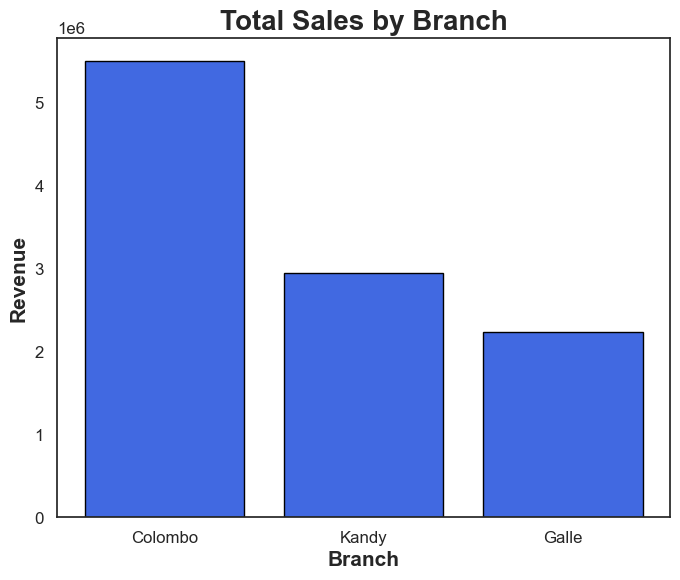

In [668]:
# Visualize sales by branch using a bar chart

plt.figure(figsize=(7,6))

plt.bar(branch_sales['Branch'], branch_sales['Total'], color='royalblue', edgecolor='black')

plt.title("Total Sales by Branch", fontsize=20, fontweight='bold')
plt.xlabel("Branch", fontsize=15, fontweight='bold')
plt.ylabel("Revenue", fontsize=15, fontweight='bold')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Finding:** Colombo branch generates the highest revenue, while Galle contributes the least.

## 9. Sales by Product Category
Analyze which product types bring the most income.

In [669]:
# Calculate total sales by product category using groupby and sort the results in descending order

category_sales = df.groupby('Product_Category')['Total'].sum().sort_values(ascending=False)
category_sales


Product_Category
Electronics      4010868.47
Food             2500763.52
Household        2068873.92
Personal Care    1522994.54
Beverages         586353.43
Name: Total, dtype: float64

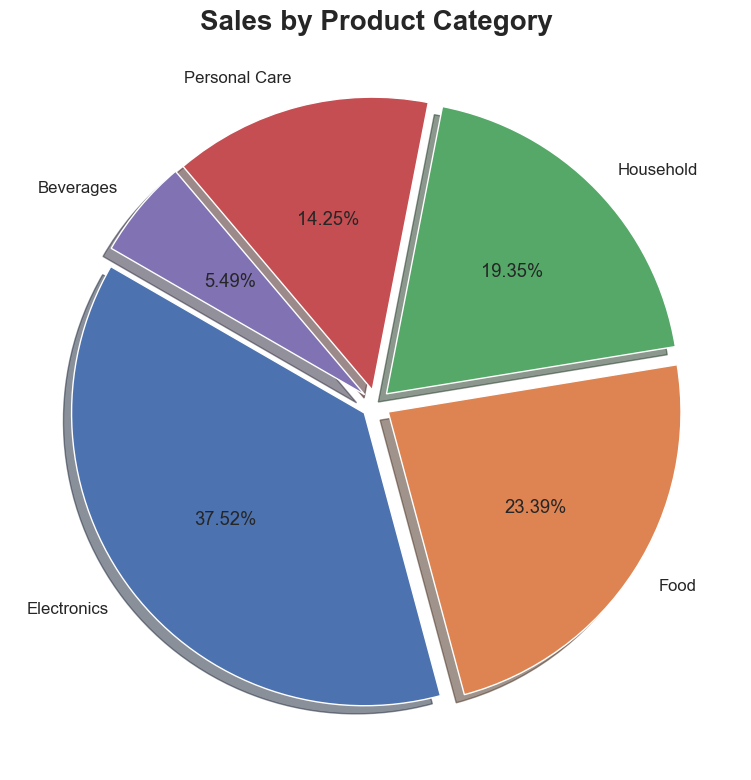

In [670]:
# Visualize sales by product category using a pie chart

plt.figure(figsize=(8, 8))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.2f%%',
    startangle=150,
    shadow=True,
    explode=[0.05]*len(category_sales)
)

plt.title("Sales by Product Category", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** Electronics dominates sales, while Beverages generate the least revenue.

## 10. Peak Shopping Hours
Analyze customer activity across different hours of the day.

In [671]:
# Calculate total sales by hour using groupby and sort the results in descending order

df.groupby('Hour')['Total'].sum().sort_values(ascending=False)

Hour
17    1278969.70
14    1163419.25
18    1141597.45
15    1077544.36
16    1057953.56
13     817923.30
19     790790.86
12     717179.35
20     595489.87
21     484855.95
10     484427.56
11     466727.42
9      348152.57
8      264822.68
Name: Total, dtype: float64

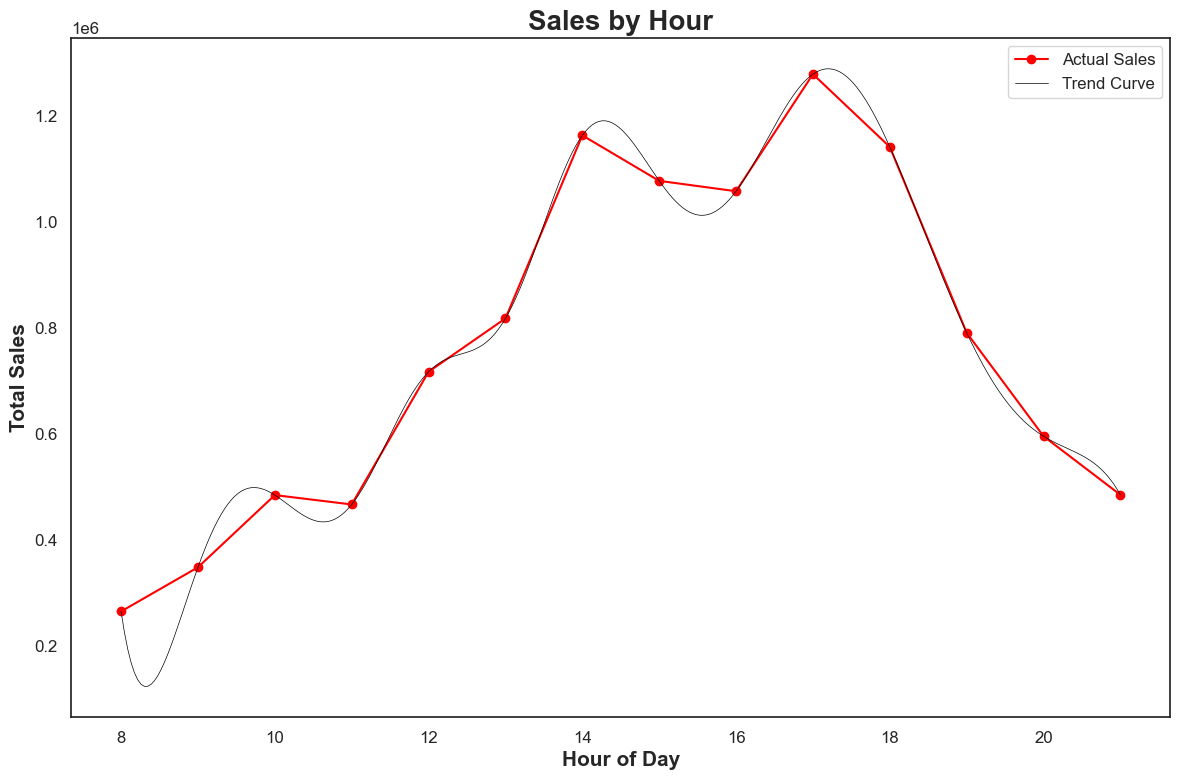

In [672]:
# Visualize sales by hour using a line chart with markers, and also trade curve

plt.figure(figsize=(12, 8))

# Actual Data
plt.plot(x, y, 
        marker='o', 
        linestyle='-', 
        color='red', 
        label='Actual Sales')

# Trend Curve
x_smooth = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=5)
y_smooth = spl(x_smooth)

plt.plot(x_smooth, y_smooth, 
        color='black', 
        linewidth=0.5, 
        label='Trend Curve')

plt.title("Sales by Hour", fontsize=20, fontweight='bold')
plt.xlabel("Hour of Day", fontsize=15, fontweight='bold')
plt.ylabel("Total Sales", fontsize=15, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

**Finding:** Peak shopping occurs in the 14:00 and 17:00 (around 14:00–17:00).

## 11. Payment Analysis
Understand how customers prefer to pay.

In [673]:
# Calculate the number of transactions for each payment method using value_counts

df['Payment'].value_counts()

Payment
Cash       683
Card       523
eZ Cash    288
Unknown      6
Name: count, dtype: int64

**Finding:** Cash is the most used payment method, followed by Card payments.

## 12. Customer Satisfaction
Evaluate average ratings per branch.

In [674]:
# Calculate the average rating for each branch using groupby and sort the results in descending order

df.groupby('Branch')['Rating'].mean().sort_values(ascending=False)

Branch
Kandy      7.216277
Colombo    7.127929
Galle      7.117763
Name: Rating, dtype: float64

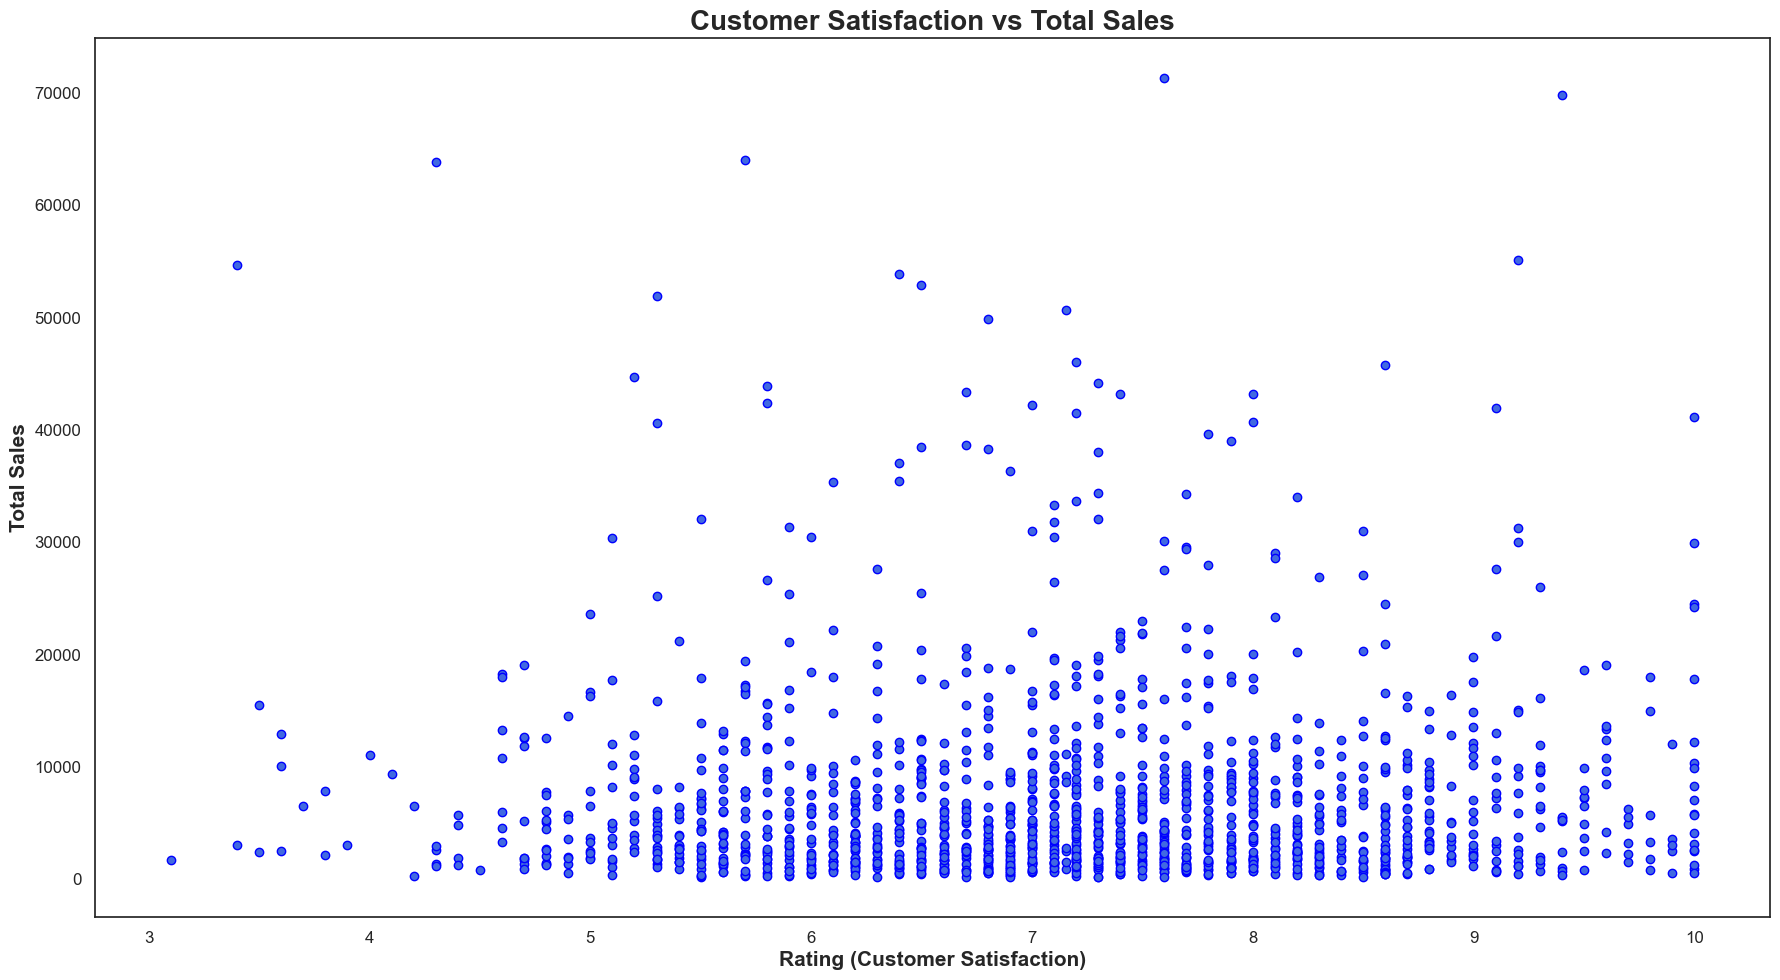

In [675]:
# Visualize Customer Satisfaction (Rating) vs Total Sales using a scatter plot

plt.figure(figsize=(18,10))

plt.scatter(df['Rating'], 
            df['Total'], 
            alpha=1, 
            color='royalblue', 
            edgecolor='blue')

plt.title("Customer Satisfaction vs Total Sales", fontsize=20, fontweight='bold')
plt.xlabel("Rating (Customer Satisfaction)", fontsize=15, fontweight='bold')
plt.ylabel("Total Sales", fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

**Finding:** Kandy has slightly higher customer satisfaction compared to other branches.

## 13. Advanced Analysis

### 13.1. Profit Estimation
Estimate profit based on 20% margin assumption.

In [676]:
# Calculate estimated profit (20% margin)

df['Estimated_Profit'] = df['Total'] * 0.20

# Calculate total estimated profit by branch and sort descending

branch_profit = df.groupby('Branch')['Estimated_Profit'].sum().sort_values(ascending=False)

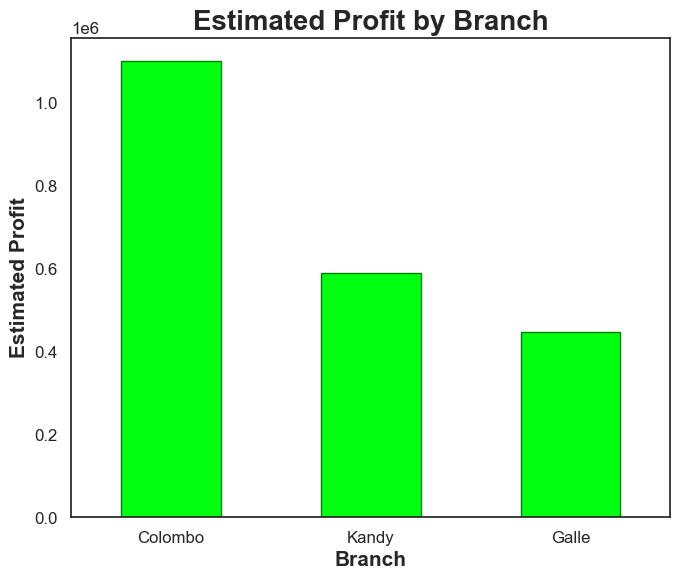

In [677]:
plt.figure(figsize=(7,6))

branch_profit.plot(kind='bar',
                color='#00FF10',
                edgecolor='green')

plt.title("Estimated Profit by Branch", fontsize=20, fontweight='bold')
plt.xlabel("Branch", fontsize=15, fontweight='bold')
plt.ylabel("Estimated Profit", fontsize=15, fontweight='bold')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 13.2. Member vs Normal Customers
Compare spending behavior.

In [678]:
# Calculate total sales, average sales, and transaction count for each customer type using groupby and agg

data = df.groupby('Customer_Type')['Total'].agg(['sum', 'mean', 'count'])
data

,sum,mean,count
Customer_Type,,,
Member,5189272.02,7477.337205,694
Normal,5500581.86,6824.543251,806


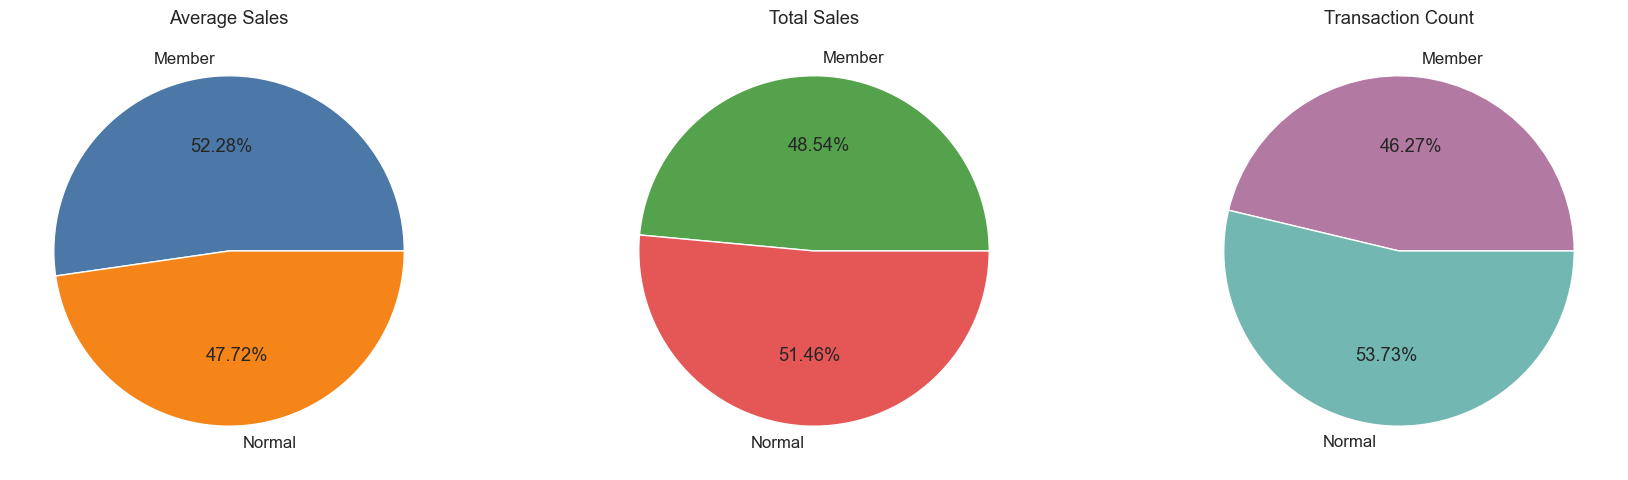

In [679]:
# Visualize Customer Type performance using three pie charts (Average Sales, Total Sales, and Transaction Count)

plt.figure(figsize=(18, 5))

# Mean
plt.subplot(1, 3, 1)
plt.pie(data['mean'], 
        labels=data.index, 
        autopct='%1.2f%%', 
        colors=['#4C78A8', '#F58518'])

plt.title("Average Sales")

# Sum
plt.subplot(1, 3, 2)
plt.pie(data['sum'], 
        labels=data.index, 
        autopct='%1.2f%%', 
        colors=['#54A24B', '#E45756'])

plt.title("Total Sales")

# Count
plt.subplot(1, 3, 3)
plt.pie(data['count'], 
        labels=data.index, 
        autopct='%1.2f%%', 
        colors=['#B279A2', '#72B7B2'])
        
plt.title("Transaction Count")

plt.tight_layout()
plt.show()

**Finding:** Member spend slightly more on average, but Normal contribute higher total sales.

### 13.3. Top Categories per Branch

In [680]:
# Calculate total sales by branch and product category using groupby and sort the results in descending order, then display the top 3 categories for each branch

sales_values = df.groupby(['Branch', 'Product_Category'])['Total'].sum().sort_values(ascending=False)
sales_values

Branch   Product_Category
Colombo  Electronics         2186796.11
         Food                1355859.09
Kandy    Electronics         1111450.45
Colombo  Household            973794.46
Galle    Electronics          712621.91
Colombo  Personal Care        688580.85
Kandy    Food                 633688.45
         Household            566660.60
Galle    Household            528418.86
         Food                 511215.98
Kandy    Personal Care        499807.70
Galle    Personal Care        334605.99
Colombo  Beverages            302883.58
Galle    Beverages            152703.29
Kandy    Beverages            130766.56
Name: Total, dtype: float64

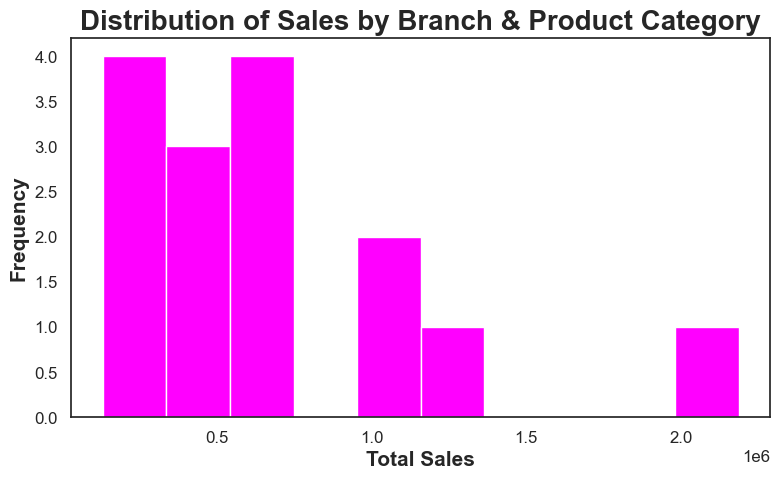

In [681]:
# Visualize the distribution of total sales across Branch and Product Category using a histogram

plt.figure(figsize=(8, 5))

plt.hist(sales_values, bins=10, color='#FF00FF')

plt.title("Distribution of Sales by Branch & Product Category", fontsize=20, fontweight='bold')
plt.xlabel("Total Sales", fontsize=15, fontweight='bold')
plt.ylabel("Frequency", fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

### 13.4. Peak Hour per Branch

In [682]:
# Calculate total sales by branch and hour using groupby and sort the results in descending order, then display the top 3 hours for each branch

# Calculate total sales by Branch and Hour
branch_hour_sales = df.groupby(['Branch', 'Hour'])['Total'].sum().reset_index()

# Sort values in descending order
branch_hour_sales = branch_hour_sales.sort_values(['Branch', 'Total'], ascending=[True, False])

# Get top 3 hours for each branch
top_3_hours = branch_hour_sales.groupby('Branch').head(3)

top_3_hours

,Branch,Hour,Total
6,Colombo,14,716945.79
7,Colombo,15,631204.41
9,Colombo,17,607513.35
23,Galle,17,379704.87
24,Galle,18,235803.86
20,Galle,14,195755.45
36,Kandy,16,340638.16
38,Kandy,18,306539.61
39,Kandy,19,302577.37


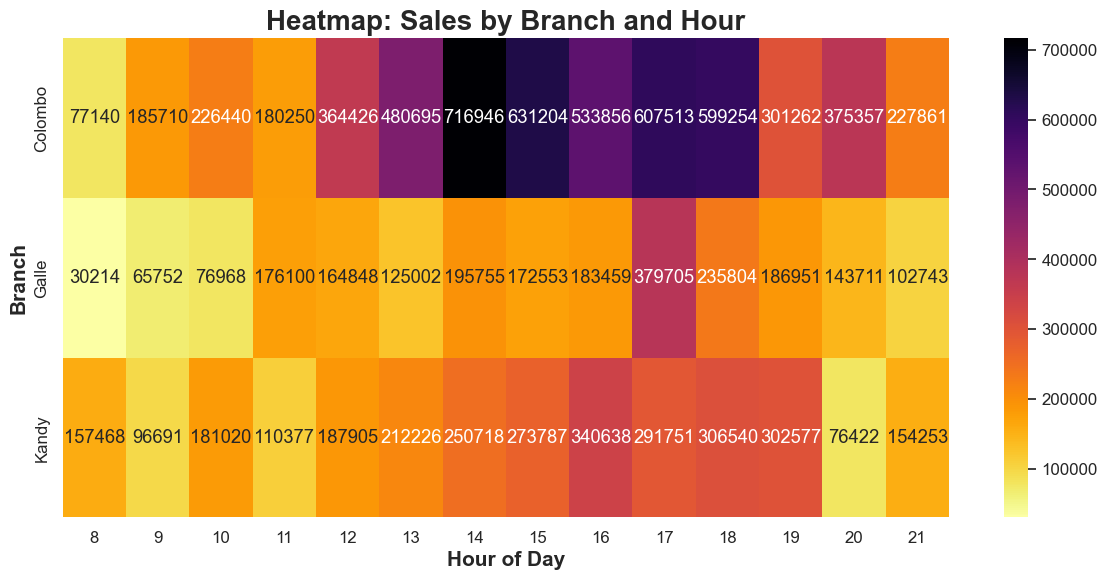

In [683]:
# Visualize sales distribution by Branch and Hour using a heatmap

heat_data = df.groupby(['Branch', 'Hour'])['Total'].sum().unstack()

plt.figure(figsize=(12, 6))

sns.heatmap(heat_data, cmap='inferno_r', annot=True, fmt='.0f')

plt.title("Heatmap: Sales by Branch and Hour", fontsize=20, fontweight='bold')
plt.xlabel("Hour of Day", fontsize=15, fontweight='bold')
plt.ylabel("Branch", fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

## 14. Feature Correlation Heatmap

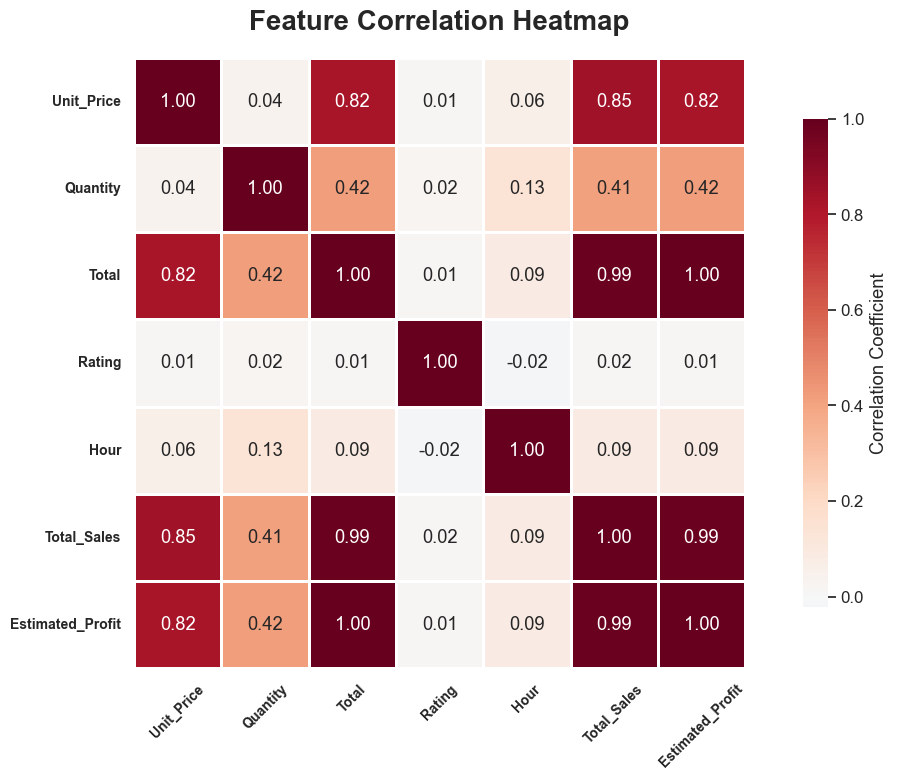

In [684]:
#visualization displays the correlation matrix of all numerical features in the dataset using a heatmap.

sns.set_theme(style="white", font_scale=1.1)

plt.figure(figsize=(12, 8))

corr = df.corr(numeric_only=True)

heatmap = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=1,
    linecolor='white',
    square=True,
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation Coefficient"
    },
    
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xticks(rotation=45, fontsize=10, fontweight='bold')
plt.yticks(rotation=0, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 15. Key Findings
- Colombo is the strongest performing branch with significantly higher revenue.
- Electronics is the most profitable product category.
- Peak shopping hours are in the 14:00 and 17:00.
- Cash dominates as the preferred payment method.
- Customer satisfaction is generally high, but Kandy performs slightly better.
- Member customers spend slightly more on average compared to normal customers.
- Normal customers contribute a higher total sales volume due to more transactions.
- Galle branch has growth potential despite currently lower revenue performance.
- Sales activity is strongest during afternoon and early evening hours.
- Customer ratings show consistent satisfaction across all branches.

## 16. Recommendations
- Increase stock and promotions for high-performing categories like Electronics.
- Improve marketing and operational efficiency in low-performing branches such as Galle.
- Allocate more staff during peak shopping hours (14:00–17:00) to reduce congestion and improve service.
- Enhance digital payment options to encourage non-cash transactions.
- Focus on improving customer service in branches with slightly lower ratings.
- Introduce loyalty rewards to increase member customer retention.
-  Launch branch-specific promotional campaigns for underperforming locations.
- Use targeted discounts during non-peak hours to balance customer traffic.
- Expand card and digital wallet payment facilities for customer convenience.
- Analyze seasonal trends to improve inventory and staffing decisions.
- Create personalized offers for frequent customers using purchase history.